<a href="https://colab.research.google.com/github/yuvalmakan/FMNIST_Spyder/blob/main/Fashion_MNIST.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importing Libraries and DATA

In [1]:
import pandas as pd
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset
import torch.optim as optim
import matplotlib.pyplot as plt
import pickle

In [2]:
# Reading the training CSV
df_train = pd.read_csv('fashion-mnist_train.csv')

# Extracting target labels
y_train = df_train['label'].values

# Dropping the label column
X_train = df_train.drop('label', axis=1).values

# Normalizing pixel values
X_train = X_train / 255.0

# Converting features to float tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)

# Converting labels to long tensors
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

In [3]:
# Reading the testing CSV
df_test = pd.read_csv('fashion-mnist_test.csv')

# Extracting labels and features
y_test = df_test['label'].values
X_test = df_test.drop('label', axis=1).values

# Normalizing pixel values
X_test = X_test / 255.0

# Converting to PyTorch tensors
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# DataSet and DataLoader

In [4]:
# Setting manual seed
torch.manual_seed(42)

In [5]:
# Checking for GPU availability
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [6]:
# Defining custom Dataset class
class CustomDataset(Dataset):

  def __init__(self, X_data, y_data):
    # Initializing parent class
    super().__init__()
    # Storing features and labels
    self.X_data = X_data
    self.y_data = y_data

  def __len__(self):
    return len(self.X_data)

  def __getitem__(self, index):
    return self.X_data[index], self.y_data[index]

In [7]:
# Defining hyperparameters
epochs = 24
lr = 0.005
batch_size = 128
momentum = 0.9
label_smoothing = 0.025

In [8]:
# Instantiating dataset objects
train_dataset = CustomDataset(X_train_tensor, y_train_tensor)
test_dataset = CustomDataset(X_test_tensor, y_test_tensor)

In [9]:
# Creating training and testing DataLoader
train_data_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, prefetch_factor=2, pin_memory=True)
test_data_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, prefetch_factor=2, pin_memory=True)





# Making The Model Class and a few utilities

In [10]:
# Defining neural network architecture
class Model(nn.Module):

  def __init__(self, num_inp_features):
    super().__init__()
    # Defining input layer
    self.linear1 = nn.Linear(num_inp_features, 16)

    # Defining Branch A layers
    self.linear2A = nn.Linear(16, 8)
    self.linear3A = nn.Linear(8, 8)

    # Defining Branch B layers
    self.linear2B = nn.Linear(16, 12)
    self.linear3B = nn.Linear(12, 8)

    # Defining output layer
    self.linearOut = nn.Linear(16, 10)

    # Defining activation function
    self.leaky_relu = nn.LeakyReLU(negative_slope=0.01)

  def forward(self, X):
    # Processing input layer
    z1 = self.linear1(X)
    a1 = self.leaky_relu(z1)

    # Processing Branch A
    z2A = self.linear2A(a1)
    a2A = self.leaky_relu(z2A)
    z3A = self.linear3A(a2A)
    a3A = self.leaky_relu(z3A)
    outA = a2A + a3A

    # Processing Branch B
    z2B = self.linear2B(a1)
    a2B = self.leaky_relu(z2B)
    z3B = self.linear3B(a2B)
    a3B = self.leaky_relu(z3B)

    # Concatenating branch outputs
    combined = torch.cat((outA, a3B), dim=1)

    # Generating final logits
    z4 = self.linearOut(combined)
    return z4

In [11]:
# Instantiating the model
model = Model(784)

# Moving model to device
model = model.to(device)

# Defining loss function
loss_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing)

# Defining optimizer
optimizer = optim.SGD(model.parameters(), lr=lr, momentum=momentum)

# Initializing tracking lists
train_losses = []
val_losses = []
accuracies = []
Epochs = []

# Training our neural Network

In [12]:
# Starting training loop
for epoch in range(epochs):
    # Setting training mode
    model.train()
    tot_loss = 0

    # Iterating through training batches
    if __name__ == '__main__':
      for batch_features, batch_labels in train_data_loader:
        # Moving data to device
        batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

        # Getting model predictions
        y_pred = model(batch_features)

        # Calculating batch loss
        loss = loss_fn(y_pred, batch_labels)

        # Clearing old gradients
        optimizer.zero_grad()

        # Calculating new gradients
        loss.backward()

        # Updating model weights
        optimizer.step()

        # Accumulating total loss
        tot_loss += loss.item()

      # Checking for even epochs
      if (epoch+1) % 1 == 0:
        # Saving training loss
        net_loss = tot_loss / len(train_data_loader)
        train_losses.append(net_loss)

        val_loss = 0.0
        total = 0
        count = 0

        # Setting evaluation mode
        model.eval()

        # Disabling gradient tracking
        with torch.no_grad():
            # Iterating through testing batches
            for batch_features, batch_labels in test_data_loader:
              batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

              # Getting test predictions
              outputs = model(batch_features)

              # Calculating validation loss
              loss = loss_fn(outputs, batch_labels)
              val_loss += loss.item()

              # Extracting predicted classes
              _ , predicted = torch.max(outputs, 1)

              # Tracking correct predictions
              total += batch_features.shape[0]
              count += (predicted == batch_labels).sum().item()

        # Saving validation metrics
        val_losses.append(val_loss / len(test_data_loader))
        accuracy = 100 * count / total
        accuracies.append(accuracy)
        Epochs.append(epoch)

        # Printing epoch progress
        print(f"epoch: {epoch+1}/{epochs} - Loss: {net_loss:.4f}, Validation loss: {val_loss/len(test_data_loader):.4f}, Accuracy: {accuracy:.2f}%")

epoch: 1/24 - Loss: 1.5107, Validation loss: 1.0107, Accuracy: 67.44%
epoch: 2/24 - Loss: 0.8763, Validation loss: 0.8060, Accuracy: 75.66%
epoch: 3/24 - Loss: 0.7400, Validation loss: 0.6963, Accuracy: 81.04%
epoch: 4/24 - Loss: 0.6707, Validation loss: 0.6755, Accuracy: 81.56%
epoch: 5/24 - Loss: 0.6313, Validation loss: 0.6389, Accuracy: 82.69%
epoch: 6/24 - Loss: 0.6023, Validation loss: 0.6076, Accuracy: 83.69%
epoch: 7/24 - Loss: 0.5837, Validation loss: 0.5848, Accuracy: 84.86%
epoch: 8/24 - Loss: 0.5696, Validation loss: 0.5771, Accuracy: 85.16%
epoch: 9/24 - Loss: 0.5562, Validation loss: 0.5667, Accuracy: 85.13%
epoch: 10/24 - Loss: 0.5487, Validation loss: 0.5507, Accuracy: 86.07%
epoch: 11/24 - Loss: 0.5374, Validation loss: 0.5460, Accuracy: 85.91%
epoch: 12/24 - Loss: 0.5336, Validation loss: 0.5447, Accuracy: 85.82%
epoch: 13/24 - Loss: 0.5268, Validation loss: 0.5433, Accuracy: 86.07%
epoch: 14/24 - Loss: 0.5231, Validation loss: 0.5560, Accuracy: 85.66%
epoch: 15/24 - 

# Plotting the graphs

In [13]:
# Setting evaluation mode
model.eval()

Model(
  (linear1): Linear(in_features=784, out_features=16, bias=True)
  (linear2A): Linear(in_features=16, out_features=8, bias=True)
  (linear3A): Linear(in_features=8, out_features=8, bias=True)
  (linear2B): Linear(in_features=16, out_features=12, bias=True)
  (linear3B): Linear(in_features=12, out_features=8, bias=True)
  (linearOut): Linear(in_features=16, out_features=10, bias=True)
  (leaky_relu): LeakyReLU(negative_slope=0.01)
)

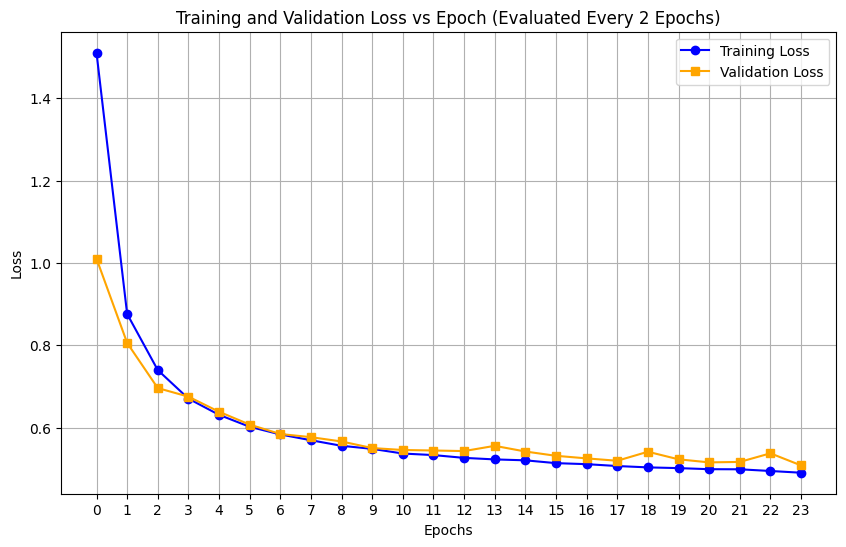

In [14]:
# Creating loss plot
plt.figure(figsize=(10, 6))

# Plotting training and validation loss
plt.plot(Epochs, train_losses, marker='o', label='Training Loss', color='blue')
plt.plot(Epochs, val_losses, marker='s', label='Validation Loss', color='orange')

# Formatting loss plot
plt.title('Training and Validation Loss vs Epoch (Evaluated Every 2 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(Epochs)
plt.legend()
plt.grid(True)

# Saving the plot
plt.savefig("Loss Graph.png")

# Displaying loss plot
plt.show()

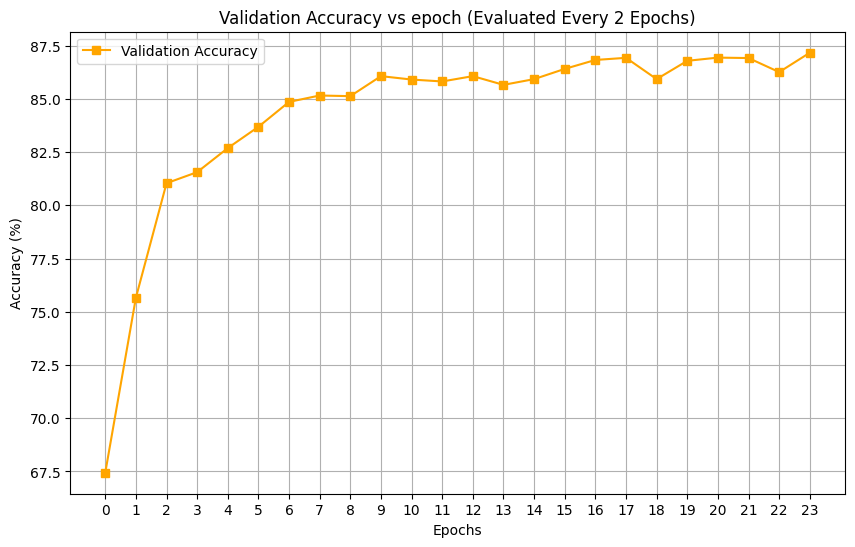

In [15]:
# Creating accuracy plot
plt.figure(figsize=(10, 6))

# Plotting validation accuracy
plt.plot(Epochs, accuracies, marker='s', label='Validation Accuracy', color='orange')

# Formatting accuracy plot
plt.title('Validation Accuracy vs epoch (Evaluated Every 2 Epochs)')
plt.xlabel('Epochs')
plt.ylabel('Accuracy (%)')
plt.xticks(Epochs)
plt.legend()
plt.grid(True)

# Saving the plot
plt.savefig("Accuracy Graph.png")

# Displaying accuracy plot
plt.show()

In [16]:
total = 0
count = 0
# Initializing predictions list
all_predictions = []

# Disabling gradient engine
with torch.no_grad():
  # Iterating through testing batches
  for batch_features, batch_labels in test_data_loader:
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    # Getting model outputs
    outputs = model(batch_features)

    # Extracting predicted classes
    _ , predicted = torch.max(outputs, 1)

    total += batch_features.shape[0]
    count += (predicted == batch_labels).sum().item()

    # Appending predictions to list
    all_predictions.extend(predicted.cpu().numpy())

# Calculating final accuracy
accuracy = 100 * count / total
print(f"The Final accuracy of the model is: {accuracy:.2f}%")

The Final accuracy of the model is: 87.17%


# Making the submission.csv and storing the parameters using pickle

In [17]:
# Creating submission DataFrame
submission_df = pd.DataFrame({
    'Id': range(1, len(all_predictions) + 1),
    'Label': all_predictions
})

# Exporting to CSV
submission_df.to_csv('submission.csv', index=False)

In [18]:
# Pickling the model weights
with open('my_model.pkl', 'wb') as file:
    pickle.dump(model, file)